# HANDS ON COVID-19 PROJECT — COMBINED & DEPLOYABLE MODEL

This notebook combines the required data preparation and Prophet forecasting code from Part 1 and Part 2 with minimal changes. The trained model is saved as `model.pkl` for deployment.

In [8]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

warnings.filterwarnings("ignore")

In [9]:
# Load the same COVID-19 CSV used in Part 1 and Part 2
df = pd.read_csv("Covid_19_Clean_Complete 1.csv")
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [10]:
# Display all COVID records only for India.
df[df["Country/Region"] == 'India']

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia
...,...,...,...,...,...,...,...,...,...,...
47892,NaN,India,20.593684,78.96288,2020-07-23,1288108,30601,817209,440298,South-East Asia
48153,NaN,India,20.593684,78.96288,2020-07-24,1337024,31358,849432,456234,South-East Asia
48414,NaN,India,20.593684,78.96288,2020-07-25,1385635,32060,885573,468002,South-East Asia
48675,NaN,India,20.593684,78.96288,2020-07-26,1435616,32771,917568,485277,South-East Asia


In [11]:
# Find the maximum confirmed cases recorded in China.
df[df["Country/Region"] == 'China']

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48,Anhui,China,31.8257,117.2264,2020-01-22,1,0,0,1,Western Pacific
49,Beijing,China,40.1824,116.4142,2020-01-22,14,0,0,14,Western Pacific
50,Chongqing,China,30.0572,107.8740,2020-01-22,6,0,0,6,Western Pacific
51,Fujian,China,26.0789,117.9874,2020-01-22,1,0,0,1,Western Pacific
52,Gansu,China,35.7518,104.2861,2020-01-22,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
48883,Tianjin,China,39.3054,117.3230,2020-07-27,204,3,195,6,Western Pacific
48884,Tibet,China,31.6927,88.0924,2020-07-27,1,0,1,0,Western Pacific
48885,Xinjiang,China,41.1129,85.2401,2020-07-27,311,3,73,235,Western Pacific
48886,Yunnan,China,24.9740,101.4870,2020-07-27,190,2,186,2,Western Pacific


In [12]:
df.Date.value_counts()

Date
2020-01-22    261
2020-01-23    261
2020-01-24    261
2020-01-25    261
2020-01-26    261
             ... 
2020-07-23    261
2020-07-24    261
2020-07-25    261
2020-07-26    261
2020-07-27    261
Name: count, Length: 188, dtype: int64

In [13]:
# What are the data types and how many non null counts present?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [15]:
extracting_all_records_column = df[df['Date'] == '2020-01-22']
extracting_all_records_column.head(60)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.060800,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.416100,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.069100,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.473500,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.868800,151.209300,2020-01-22,0,0,0,0,Western Pacific


In [16]:
df.groupby(by='Country/Region')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

,Country/Region,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [17]:
df["Country/Region"].nunique()

187

In [3]:
# Convert date strings into datetime objects for time series analysis.
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [4]:

confirmed_cases = df.groupby(by='Date')['Confirmed'].sum().reset_index()
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [25]:

confirmed_cases.columns = ['ds', 'y']
confirmed_cases

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


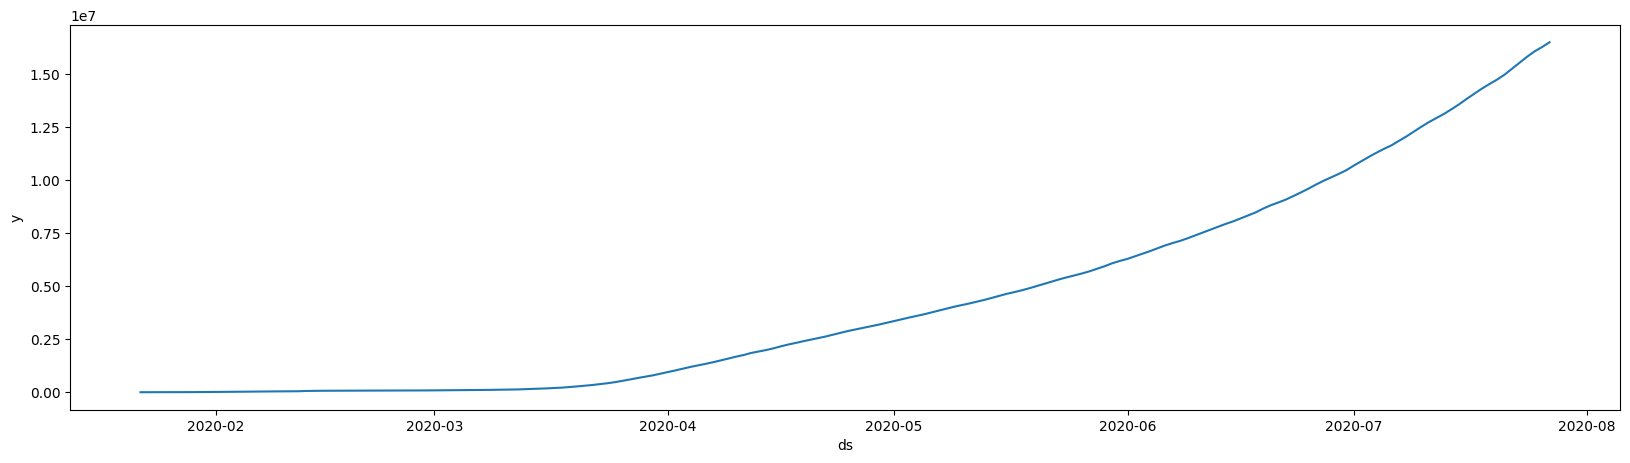

In [26]:

plt.figure(figsize=(20, 5))
sns.lineplot(data=confirmed_cases, x='ds', y='y')
plt.show()

In [18]:
Active_cases = df.groupby(by ='Date')['Active'].sum().reset_index() 
Active_cases

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


<Axes: xlabel='Date', ylabel='Active'>

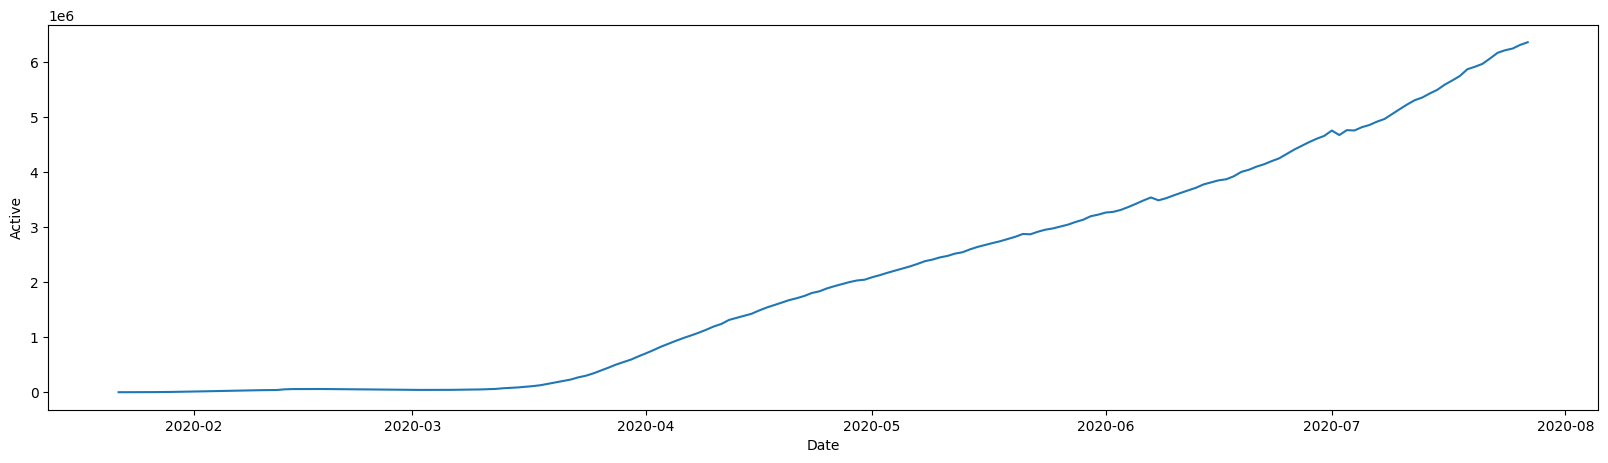

In [23]:
plt.figure(figsize = (20, 5))
sns.lineplot(data = Active_cases ,  x='Date', y ='Active')

In [19]:
Death_cases = df.groupby(by ='Date')['Deaths'].sum().reset_index() 
Death_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


<Axes: xlabel='Date', ylabel='Deaths'>

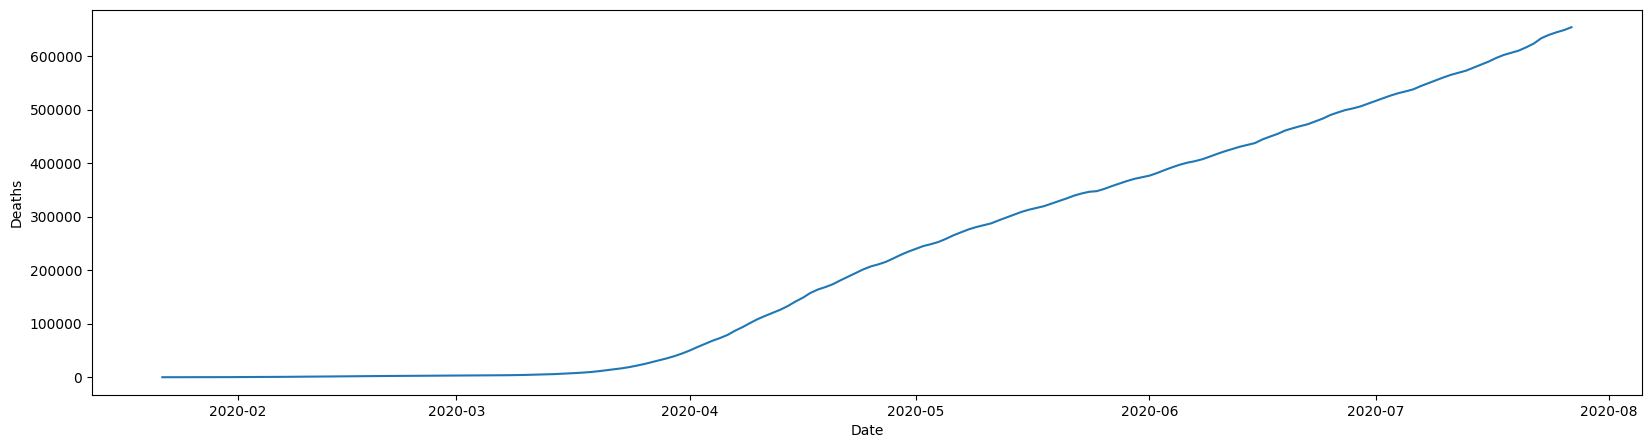

In [20]:
plt.figure(figsize = (20, 5))
sns.lineplot(data = Death_cases ,  x='Date', y ='Deaths')

In [21]:

Recovered_cases = df.groupby(by ='Date')['Recovered'].sum().reset_index()
Recovered_cases

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


<Axes: xlabel='Date', ylabel='Recovered'>

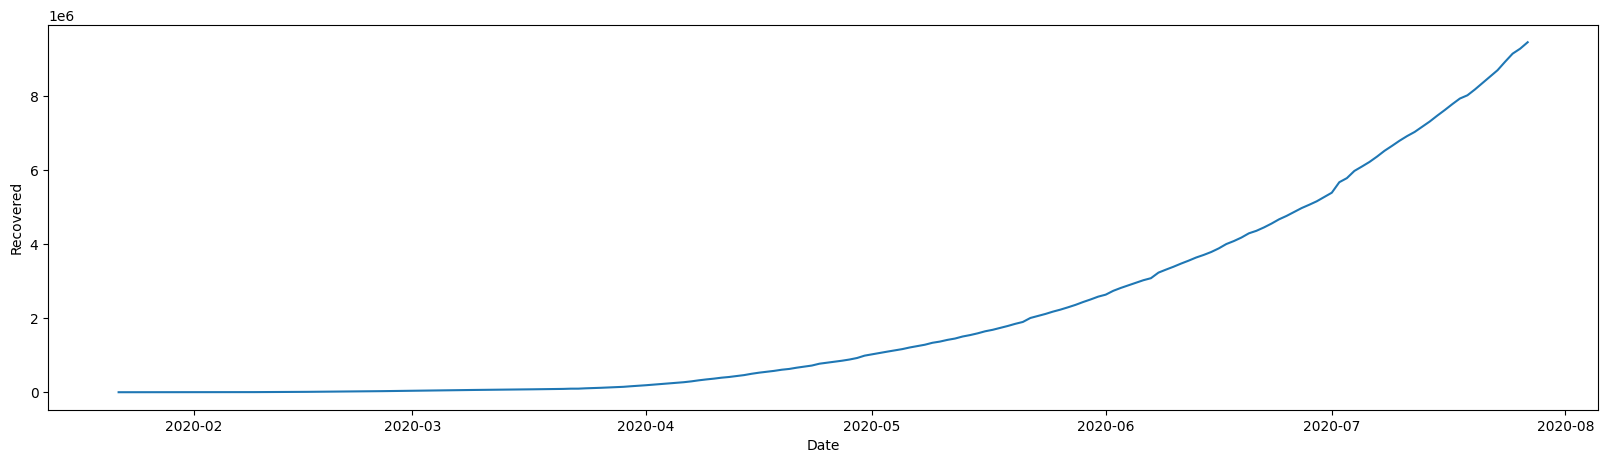

In [22]:
plt.figure(figsize = (20, 5))
sns.lineplot(data = Recovered_cases,  x='Date', y ='Recovered')

In [28]:
countries_active_cases = df.groupby(by ='Country/Region')['Active'].sum().reset_index() 
countries_active_cases

,Country/Region,Active
0,Afghanistan,1089052
1,Albania,72117
2,Algeria,345886
3,Andorra,19907
4,Angola,15011
...,...,...
182,West Bank and Gaza,170967
183,Western Sahara,190
184,Yemen,25694
185,Zambia,43167


In [29]:

top_10_countries_active_cases = countries_active_cases.sort_values(by ='Active', ascending = False).head(10)
top_10_countries_active_cases

,Country/Region,Active
173,US,156981121
23,Brazil,31094060
177,United Kingdom,22624595
138,Russia,19668578
79,India,15987913
61,France,10980287
157,Spain,9277432
32,Canada,8656985
132,Peru,7748957
85,Italy,7363518


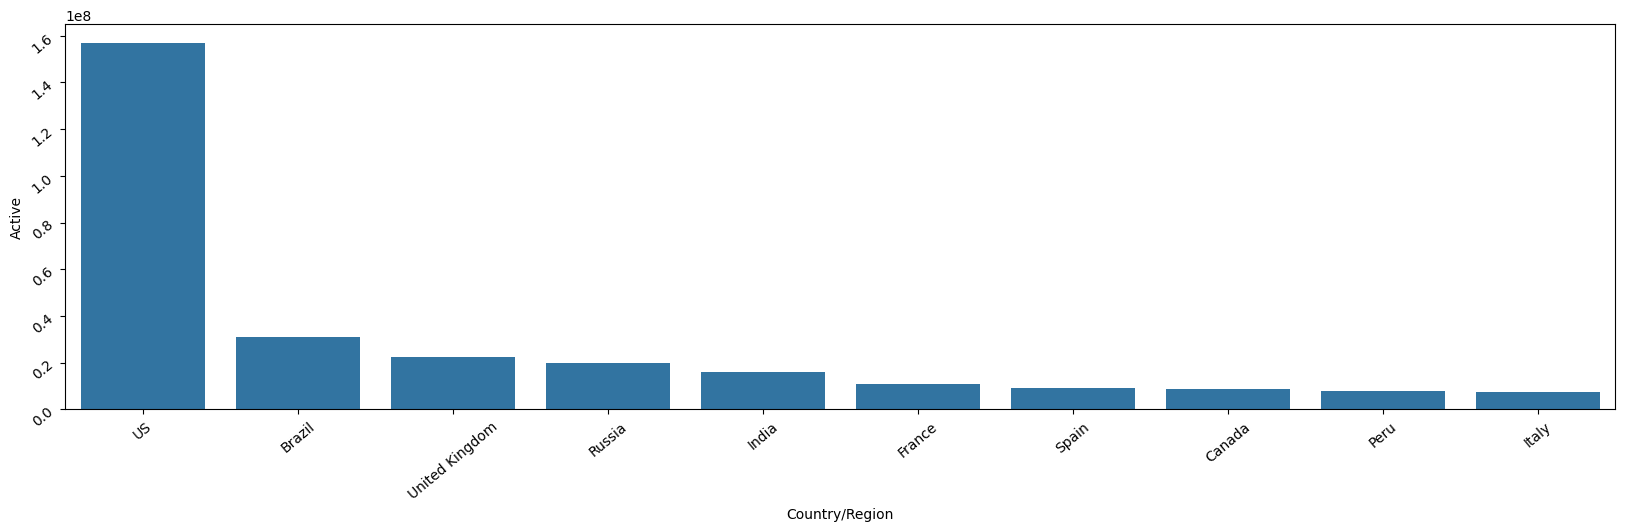

In [30]:
plt.figure(figsize =(20, 5))
sns.barplot(x ='Country/Region', y ='Active', data = top_10_countries_active_cases)
plt.xticks(rotation = 40)
plt.yticks(rotation = 40)
plt.show()

In [34]:
df[df['Country/Region'].isin(['India', 'China', 'US'])].groupby(['Date', 'Country/Region'])[['Deaths']].sum().reset_index()

,Date,Country/Region,Deaths
0,2020-01-22,China,17
1,2020-01-22,India,0
2,2020-01-22,US,0
3,2020-01-23,China,18
4,2020-01-23,India,0
...,...,...,...
559,2020-07-26,India,32771
560,2020-07-26,US,146935
561,2020-07-27,China,4656
562,2020-07-27,India,33408


In [35]:

all_records_india = df[df["Country/Region"] == 'India']
all_records_india

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia
...,...,...,...,...,...,...,...,...,...,...
47892,NaN,India,20.593684,78.96288,2020-07-23,1288108,30601,817209,440298,South-East Asia
48153,NaN,India,20.593684,78.96288,2020-07-24,1337024,31358,849432,456234,South-East Asia
48414,NaN,India,20.593684,78.96288,2020-07-25,1385635,32060,885573,468002,South-East Asia
48675,NaN,India,20.593684,78.96288,2020-07-26,1435616,32771,917568,485277,South-East Asia


In [36]:
total_deaths_india = all_records_india.groupby(by ='Date')['Deaths'].sum().reset_index() 
total_deaths_india

,Date,Deaths
0,2020-01-22,0
1,2020-01-23,0
2,2020-01-24,0
3,2020-01-25,0
4,2020-01-26,0
...,...,...
183,2020-07-23,30601
184,2020-07-24,31358
185,2020-07-25,32060
186,2020-07-26,32771


In [37]:
all_records_China = df[df["Country/Region"] == 'China']
all_records_China

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48,Anhui,China,31.8257,117.2264,2020-01-22,1,0,0,1,Western Pacific
49,Beijing,China,40.1824,116.4142,2020-01-22,14,0,0,14,Western Pacific
50,Chongqing,China,30.0572,107.8740,2020-01-22,6,0,0,6,Western Pacific
51,Fujian,China,26.0789,117.9874,2020-01-22,1,0,0,1,Western Pacific
52,Gansu,China,35.7518,104.2861,2020-01-22,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
48883,Tianjin,China,39.3054,117.3230,2020-07-27,204,3,195,6,Western Pacific
48884,Tibet,China,31.6927,88.0924,2020-07-27,1,0,1,0,Western Pacific
48885,Xinjiang,China,41.1129,85.2401,2020-07-27,311,3,73,235,Western Pacific
48886,Yunnan,China,24.9740,101.4870,2020-07-27,190,2,186,2,Western Pacific


In [38]:
total_deaths_china = all_records_China.groupby(by ='Date')['Deaths'].sum().reset_index()
total_deaths_china

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,4649
184,2020-07-24,4650
185,2020-07-25,4652
186,2020-07-26,4652


In [39]:
all_records_US = df[df["Country/Region"] == 'US']
all_records_US

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas


In [40]:

total_deaths_us = all_records_US.groupby(by ='Date')['Deaths'].sum().reset_index()
total_deaths_us

,Date,Deaths
0,2020-01-22,0
1,2020-01-23,0
2,2020-01-24,0
3,2020-01-25,0
4,2020-01-26,0
...,...,...
183,2020-07-23,144430
184,2020-07-24,145560
185,2020-07-25,146465
186,2020-07-26,146935


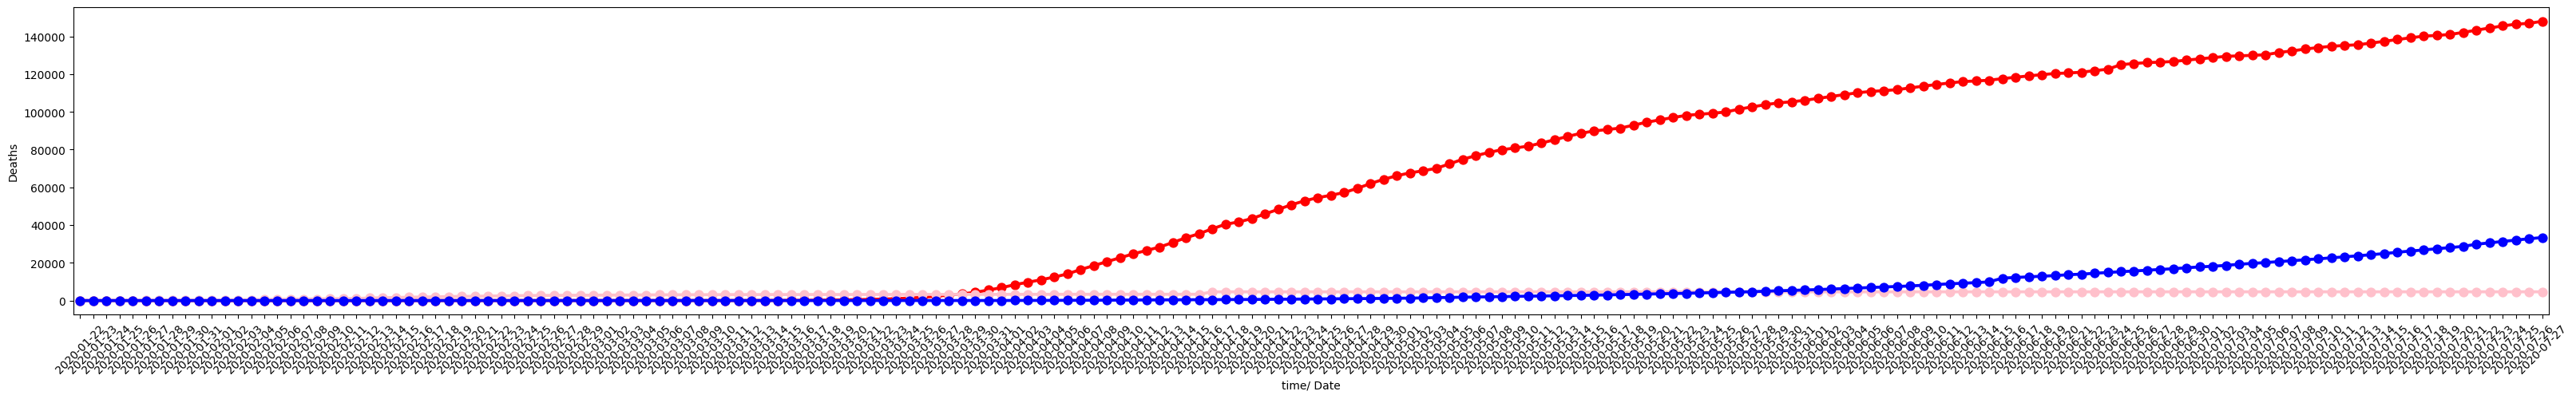

In [41]:

plt.figure(figsize =(40, 5))
sns.pointplot(x = total_deaths_us.Date, y = total_deaths_us.Deaths, color ='red')

sns.pointplot(x = total_deaths_china.Date, y = total_deaths_china.Deaths, color ='Pink')

sns.pointplot(x = total_deaths_india.Date, y = total_deaths_india.Deaths, color ='Blue')

plt.xlabel('time/ Date')
plt.xticks(rotation = 45)
plt.show()

In [42]:
from prophet import Prophet

In [43]:
# Train the Prophet forecasting model.
fp_prophet_model = Prophet()
fp_prophet_model.fit(confirmed_cases)

01:05:23 - cmdstanpy - INFO - Chain [1] start processing
01:05:24 - cmdstanpy - INFO - Chain [1] done processing


In [44]:
# Forecast the next 15 days.
forecated_future_values = fp_prophet_model.make_future_dataframe(periods=15)
forecated_future_values

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
198,2020-08-07
199,2020-08-08
200,2020-08-09
201,2020-08-10


In [46]:

predicted_future_values = fp_prophet_model.predict(forecated_future_values)
predicted_future_values[['ds', 'yhat', 'yhat_upper', 'yhat_lower']]

,ds,yhat,yhat_upper,yhat_lower
0,2020-01-22,-2.049744e+04,8.731582e+04,-1.285472e+05
1,2020-01-23,-7.896286e+03,9.747836e+04,-1.226368e+05
2,2020-01-24,5.975182e+03,1.133986e+05,-1.007808e+05
3,2020-01-25,1.237060e+04,1.150180e+05,-9.515976e+04
4,2020-01-26,8.615242e+03,1.278073e+05,-1.025114e+05
...,...,...,...,...
198,2020-08-07,1.838711e+07,1.852342e+07,1.824620e+07
199,2020-08-08,1.859481e+07,1.874652e+07,1.845560e+07
200,2020-08-09,1.879236e+07,1.895374e+07,1.862864e+07
201,2020-08-10,1.898699e+07,1.914914e+07,1.881835e+07


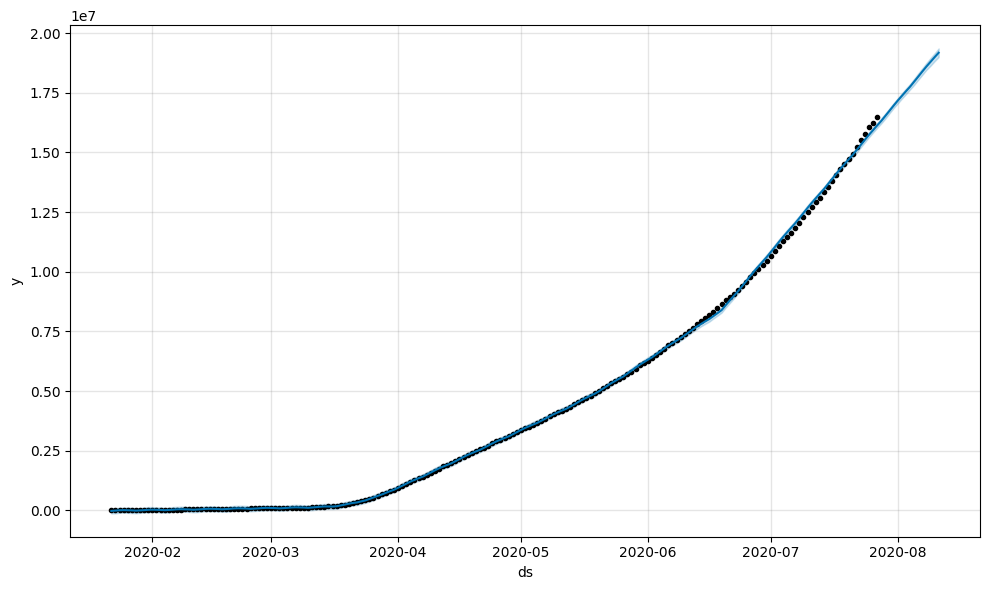

In [47]:
# Plot the Prophet forecast.
fp_prophet_model.plot(predicted_future_values)
plt.show()

## Save the trained model for deployment

In [14]:
# Save the complete trained Prophet model as model.pkl.
with open('model.pkl', 'wb') as model_file:
    pickle.dump(fp_prophet_model, model_file)

print('model.pkl saved successfully.')

model.pkl saved successfully.


## Deployment / Prediction Test

In [15]:
# Load the saved model exactly as it can be loaded in a deployment application.
with open('model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

# Generate predictions from the saved model.
deployment_future_values = loaded_model.make_future_dataframe(periods=15)
deployment_predictions = loaded_model.predict(deployment_future_values)
deployment_predictions[['ds', 'yhat', 'yhat_upper', 'yhat_lower']].tail(15)

,ds,yhat,yhat_upper,yhat_lower
188,2020-07-28,1.632012e+07,1.642058e+07,1.621191e+07
189,2020-07-29,1.652995e+07,1.663238e+07,1.642580e+07
190,2020-07-30,1.674386e+07,1.685508e+07,1.663554e+07
191,2020-07-31,1.695903e+07,1.706914e+07,1.685194e+07
192,2020-08-01,1.716674e+07,1.727858e+07,1.705901e+07
193,2020-08-02,1.736429e+07,1.748035e+07,1.724095e+07
194,2020-08-03,1.755891e+07,1.766850e+07,1.744514e+07
195,2020-08-04,1.774819e+07,1.787593e+07,1.762904e+07
196,2020-08-05,1.795803e+07,1.808581e+07,1.783611e+07
197,2020-08-06,1.817193e+07,1.831178e+07,1.803766e+07
